# TTS Missing Data Analysis
## Notebook 03 — Missingness Information as Feature
**Paper**: Missing Data as a Methodological Challenge in Rare Cardiac Disease Registries  
**Dataset**: TAKO_TSUBO_EF.xls — N=57 pazienti, foglio Baseline

> **Istruzioni**: esegui le celle nell'ordine. Dopo la Cella 1 (installazione) riavvia il runtime prima di procedere.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELLA 1: INSTALLAZIONE
# Eseguire UNA VOLTA, poi riavviare il runtime:
# Runtime → Riavvia sessione
# ═══════════════════════════════════════════════════════════════

!pip install -q miceforest xlrd==2.0.1 pingouin shap

print("Installazione completata.")
print("→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 8.7 MB/s eta 0:00:00
Installazione completata.
→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELLA 2: CONFIGURAZIONE PERCORSO DRIVE
# Modifica PROJECT_FOLDER con il nome della tua cartella su MyDrive
# ═══════════════════════════════════════════════════════════════

PROJECT_FOLDER = 'TTS_Research'   # ← modifica qui con TTS_Research

BASE      = f'/content/drive/MyDrive/TTS_Research'
DATA_PATH = f'{BASE}/data/TAKO_TSUBO_EF.xls'
FIG_PATH  = f'{BASE}/outputs/figures/'
TAB_PATH  = f'{BASE}/outputs/tables/'

print(f'BASE      : {BASE}')
print(f'DATA_PATH : {DATA_PATH}')

BASE      : /content/drive/MyDrive/TTS_Research
DATA_PATH : /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELLA 3: SETUP — mount Drive, cartelle, import, seed
# Eseguire dopo il riavvio del runtime.
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os

# Crea cartelle se non esistono
for path in [f'{BASE}/data',
             f'{BASE}/outputs/figures',
             f'{BASE}/outputs/tables',
             f'{BASE}/notebooks']:
    os.makedirs(path, exist_ok=True)

# Verifica percorsi critici
for path in [BASE, DATA_PATH]:
    status = 'OK' if os.path.exists(path) else 'MANCANTE'
    print(f'{status}: {path}')

# Seed globale
import numpy as np, random
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# Import standard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.base import clone
import sklearn, warnings
from sklearn.linear_model import ElasticNetCV
warnings.filterwarnings('ignore')

print(f'pandas:  {pd.__version__}')
print(f'numpy:   {np.__version__}')
print(f'sklearn: {sklearn.__version__}')
print('Setup completato.')

Mounted at /content/drive
OK: /content/drive/MyDrive/TTS_Research
OK: /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls
pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
Setup completato.


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELLA 4: CARICAMENTO E PULIZIA DATASET
# ═══════════════════════════════════════════════════════════════

df_raw = pd.read_excel(DATA_PATH, engine='xlrd', sheet_name='Baseline')
print(f'Righe raw: {len(df_raw)}')

df = df_raw.copy()

# Verifica integrità
assert len(df) == 57, f'Attesi 57 pazienti, trovati {len(df)}'
assert df['LVEF'].notna().sum() == 57, 'LVEF non completa'

print(f'Dataset pulito: {df.shape[0]} pazienti, {df.shape[1]} variabili')
print(f'LVEF: {df["LVEF"].min():.1f} - {df["LVEF"].max():.1f}%  '
      f'(media {df["LVEF"].mean():.1f} ± {df["LVEF"].std():.1f}%)')
print(f'LVEF < 50: {(df["LVEF"]<50).sum()} pazienti | '
      f'LVEF >= 50: {(df["LVEF"]>=50).sum()} pazienti')

Righe raw: 57
Dataset pulito: 57 pazienti, 168 variabili
LVEF: 26.0 - 76.0%  (media 52.5 ± 10.7%)
LVEF < 50: 21 pazienti | LVEF >= 50: 36 pazienti


In [5]:
# ═══════════════════════════════════════════════════════════════
# SETUP AMBIENTE E CARICAMENTO DATI (NOTEBOOK 03)
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. Montaggio Google Drive (Necessario per accedere ai tuoi percorsi)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Configurazione Percorsi Globali
BASE_PATH = '/content/drive/MyDrive/TTS_Research/'
TAB_PATH  = f'{BASE_PATH}outputs/tables/'
FIG_PATH  = f'{BASE_PATH}outputs/figures/'
DATA_PATH = f'{BASE_PATH}data/TAKO_TSUBO_EF.xls' # Percorso che hai indicato

# 3. Definizioni Globali
TARGET = 'LVEF'
SEED = 42

print("--- Inizio Caricamento Asset ---")

# 4. Caricamento Output dal Notebook 1 (tab1)
try:
    tab1 = pd.read_csv(f'{TAB_PATH}tabella_01_missingness_summary.csv')
    print("Tabella 1 (Missing Summary) caricata con successo.")
except FileNotFoundError:
    print("Attenzione: Tabella 1 non trovata in Drive. Controlla il nome del file.")

# 5. Caricamento Dataset Originale e Creazione df_work
try:
    # Carichiamo l'Excel dal percorso in Drive
    df = pd.read_excel(DATA_PATH, sheet_name='Baseline')

    # Teniamo solo le colonne numeriche (fondamentale per gli indicatori M)
    df = df.select_dtypes(include=[np.number])

    # Creiamo df_work (la base per il feature engineering successivo)
    df_work = df.copy()

    print(f"Dataset caricato correttamente da: {DATA_PATH}")
    print(f"df_work pronto: {df_work.shape[0]} pazienti, {df_work.shape[1]} variabili.")

except Exception as e:
    print(f"ERRORE Critico nel caricamento dell'Excel: {e}")
    print("Controlla che il file sia effettivamente in 'tts research/data/'")

print("--- Setup Completato ---")

--- Inizio Caricamento Asset ---
Tabella 1 (Missing Summary) caricata con successo.
Dataset caricato correttamente da: /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls
df_work pronto: 57 pazienti, 149 variabili.
--- Setup Completato ---


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5: 4.1 Costruzione feature set esteso (Indicatori M)
# ═══════════════════════════════════════════════════════════════

feat_cols = [c for c in df_work.columns if c != 'LVEF']

# Creo una matrice di 0 e 1: 1 se il dato manca, 0 se è presente
miss_ind = df[feat_cols].isna().astype(int)

# Rinomino le colonne aggiungendo il prefisso 'M_'
miss_ind.columns = ['M_' + c for c in feat_cols]

# Teniamo solo gli indicatori che hanno almeno 5 valori mancanti
# (sotto i 5 non c'è abbastanza varianza per imparare qualcosa)
useful_M = [c for c in miss_ind.columns if miss_ind[c].sum() >= 5]
miss_ind_useful = miss_ind[useful_M]

print(f"Feature originali: {len(feat_cols)}")
print(f"Indicatori M aggiunti (con almeno 5 missing): {len(useful_M)}")
print(f"Esempi di indicatori creati: {useful_M[:5]}")

# Salviamo questo set per il confronto successivo
df_extended = pd.concat([df_work, miss_ind_useful], axis=1)

Feature originali: 148
Indicatori M aggiunti (con almeno 5 missing): 148
Esempi di indicatori creati: ['M_MEAN LIVER T1 MAPPING', 'M_mid', 'M_basal', 'M_Age', 'M_Sex']


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELLA 6: 4.2 Confronto BASE vs EXTENDED
# ═══════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon
import time

def loocv_fast(df_w, use_extended=False, seed=42):
    target_col = 'LVEF'
    if use_extended:
        feat = [c for c in df_w.columns if c != target_col]
    else:
        feat = [c for c in df_w.columns if c != target_col and not c.startswith('M_')]

    errori = []

    imp = KNNImputer(n_neighbors=5)

    for i in range(len(df_w)):
        # Split Training/Test
        tr = df_w.drop(index=df_w.index[i]).reset_index(drop=True)
        te = df_w.iloc[[i]].reset_index(drop=True)

        X_tr, y_tr = tr[feat].values, tr[target_col].values
        X_te, y_te = te[feat].values, te[target_col].values[0]

        # Imputazione Rapida
        X_tr_i = imp.fit_transform(X_tr)
        X_te_i = imp.transform(X_te)

        # Scaling e Modello (n_jobs=-1 velocizza la ricerca dei parametri)
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr_i)
        X_te_sc = sc.transform(X_te_i)

        m = ElasticNetCV(cv=5, random_state=seed, n_jobs=-1)
        m.fit(X_tr_sc, y_tr)

        errori.append(abs(m.predict(X_te_sc)[0] - y_te))
    return errori

start_time = time.time()

print("Calcolo errori modello BASE (Rapido)...")
err_base = loocv_fast(df_extended, use_extended=False)

print("Calcolo errori modello EXTENDED (Rapido)...")
err_ext = loocv_fast(df_extended, use_extended=True)

# Test di Wilcoxon
stat, p_val = wilcoxon(err_base, err_ext)

durata = (time.time() - start_time) / 60

print("\n" + "═"*40)
print(f" RISULTATI CONFRONTO (Tempo: {durata:.2f} min)")
print("═"*40)
print(f"MAE Base:     {np.mean(err_base):.3f}")
print(f"MAE Extended: {np.mean(err_ext):.3f}")
print(f"P-value:      {p_val:.4f}")
print("═"*40)

if p_val < 0.05:
    print("CONCLUSIONE: Gli indicatori M sono significativi!")
else:
    print("CONCLUSIONE: Non c'è differenza statistica, ma procediamo con SHAP per i dettagli.")

Calcolo errori modello BASE (Rapido)...
Calcolo errori modello EXTENDED (Rapido)...

════════════════════════════════════════
 RISULTATI CONFRONTO (Tempo: 1.55 min)
════════════════════════════════════════
MAE Base:     9.532
MAE Extended: 8.488
P-value:      0.6941
════════════════════════════════════════
CONCLUSIONE: Non c'è differenza statistica, ma procediamo con SHAP per i dettagli.


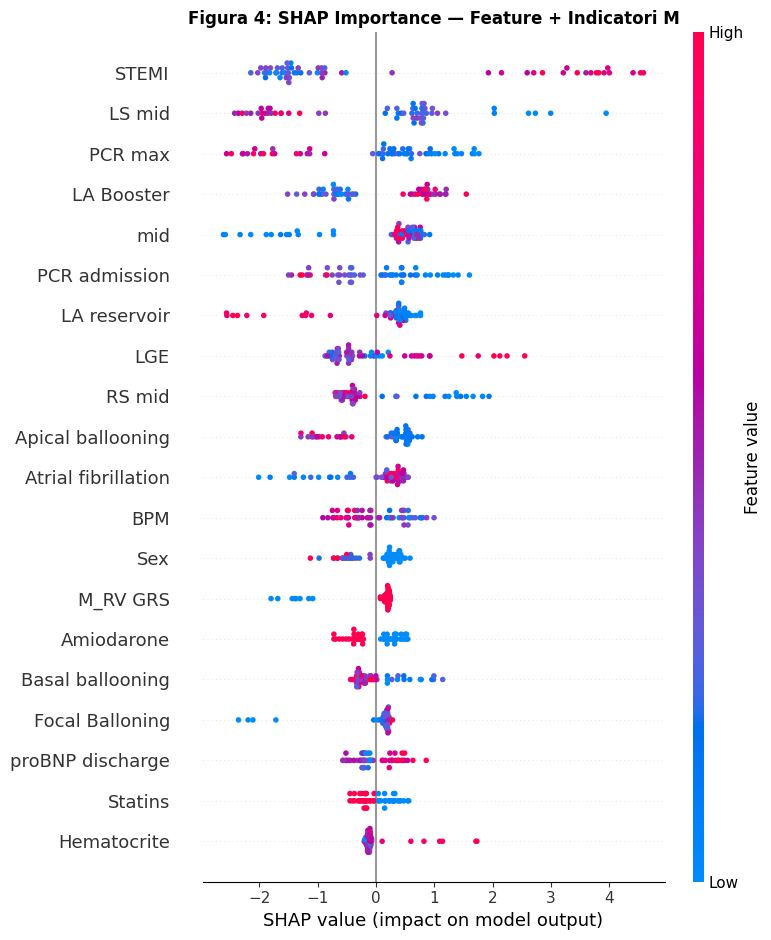


NOTA: Se nessun indicatore 'M_' compare tra le top-15, documentalo.
Grafico salvato in: /content/drive/MyDrive/TTS_Research/outputs/figures/figura_04_shap_beeswarm.png


In [8]:

# ═══════════════════════════════════════════════════════════════
# CELLA 7: 4.3 SHAP Analysis — Importanza delle Feature + Indicatori M
# ═══════════════════════════════════════════════════════════════

import shap
from xgboost import XGBRegressor

# Usiamo l'imputazione KNN rapida solo per questa analisi di importanza
imp = KNNImputer(n_neighbors=5)
X_imp = imp.fit_transform(df_work[feat_cols])

# Uniamo i dati imputati con gli indicatori M (df_extended contiene tutto)
X_ext = np.hstack([X_imp, miss_ind_useful.values])
all_names = feat_cols + list(miss_ind_useful.columns)
y = df_work['LVEF'].values

# 2. Addestramento del modello XGBoost (ottimo per SHAP)
xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                   subsample=0.8, random_state=42, verbosity=0)
xgb.fit(X_ext, y)

# 3. Calcolo dei valori SHAP
explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_ext)

# 4. Visualizzazione Figura 4: SHAP Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_ext, feature_names=all_names, max_display=20, show=False)

plt.title('Figura 4: SHAP Importance — Feature + Indicatori M', fontweight='bold')
plt.tight_layout()

plt.savefig(f'{FIG_PATH}figura_04_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nNOTA: Se nessun indicatore 'M_' compare tra le top-15, documentalo.")
print(f"Grafico salvato in: {FIG_PATH}figura_04_shap_beeswarm.png")

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELLA 8: FREEZE AMBIENTE — eseguire a fine fase
# Salva le versioni esatte dei pacchetti per riproducibilità.
# ═══════════════════════════════════════════════════════════════

import subprocess
req_path = f'{BASE}/requirements_fase1.txt'
with open(req_path, 'w') as f:
    result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
    f.write(result.stdout)
print(f'Environment salvato in: {req_path}')

Environment salvato in: /content/drive/MyDrive/TTS_Research/requirements_fase1.txt
